In [1]:
# Recurrent Neural Network (RNN)
# Google Stock Price Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dropout

from sklearn.metrics import mean_squared_error

In [3]:
# Load Dataset

dataset_train = pd.read_csv("Google_Stock_Price_Train.csv")
dataset_test = pd.read_csv("Google_Stock_Price_Test.csv")

In [4]:
# Select Open Price Column

training_set = dataset_train.iloc[:, 1:2].values

In [6]:
# Feature Scaling

scaler = MinMaxScaler(feature_range=(0,1))
training_set_scaled = scaler.fit_transform(training_set)

In [7]:
# Create Data for RNN

X_train = []
y_train = []
for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
    
X_train = np.array(X_train)
y_train = np.array(y_train)

In [8]:
# Reshape for RNN

X_train = np.reshape(
    X_train,
    (X_train.shape[0], X_train.shape[1], 1)
)

In [9]:
# Build RNN Model

model = Sequential()

In [10]:
# First RNN Layer

model.add(
    SimpleRNN(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

model.add(Dropout(0.2))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
# Second RNN Layer

model.add(
    SimpleRNN(
        units=50,
        return_sequences=True
    )
)

model.add(Dropout(0.2))

In [12]:
# Third RNN Layer

model.add(
    SimpleRNN(
        units=50
    )
)

model.add(Dropout(0.2))

In [13]:
# Output Layer

model.add(Dense(units=1))

In [14]:
# Compile Model

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [15]:
# Train Model

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1795
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0687 
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0386 
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0316 
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0229 
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0201 
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0180 
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0167 
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0134 
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0127 
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0121 
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0106 
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0097 
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0085 
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0082 
Epoch

In [16]:
# Prepare Test Data

real_stock_price = dataset_test.iloc[:, 1:2].values
dataset_total = pd.concat(
    (dataset_train['Open'], dataset_test['Open']),
    axis=0
)
inputs = dataset_total[
    len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = scaler.transform(inputs)
X_test = []
for i in range(60, 60 + len(dataset_test)):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)

In [17]:
# Reshape Test Data

X_test = np.reshape(
    X_test,
    (X_test.shape[0], X_test.shape[1], 1)
)

In [18]:
# Predict Stock Prices

predicted_stock_price = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


In [19]:
# Inverse Transform

predicted_stock_price = scaler.inverse_transform(

    predicted_stock_price

)

In [20]:
# RMSE

rmse = np.sqrt(
    mean_squared_error(
        real_stock_price,
        predicted_stock_price
    )
)

print("RMSE :", rmse)

RMSE : 10.89181917493844


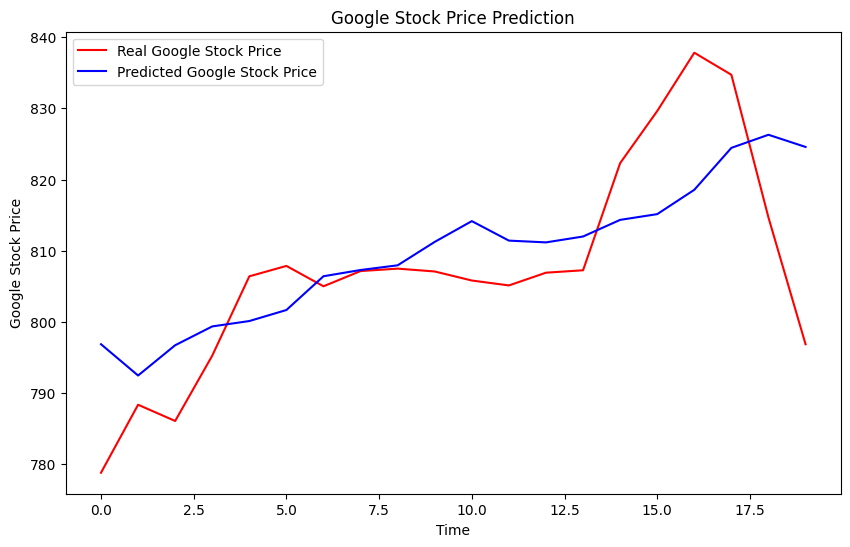

In [21]:
# Visualization

plt.figure(figsize=(10,6))
plt.plot(
    real_stock_price,
    color='red',
    label='Real Google Stock Price'
)
plt.plot(
    predicted_stock_price,
    color='blue',
    label='Predicted Google Stock Price'
)
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()